In [69]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os

TROPOMI valid pixels: 27247 / 65341
TROPOMI valid fraction: 41.70%


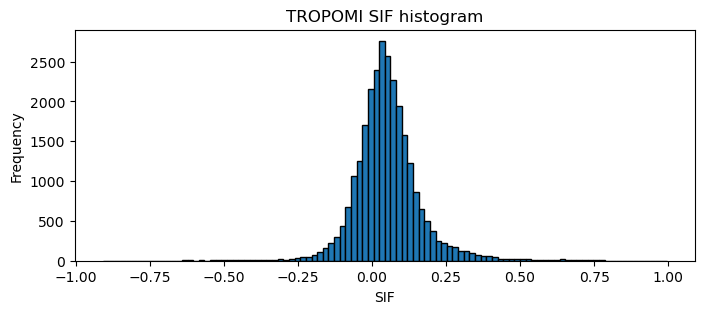

In [11]:
tropomi_raster_dir = "/kiwi-data/Data/groupMembers/zhe2/MyProjects/TROPOMI_SIF/red_rasters"
tropomi_raster_file = "red_raster_20250630_20250730_v10.nc"

ds_tropomi = xr.open_dataset(os.path.join(tropomi_raster_dir, tropomi_raster_file))

lon_tropomi = ds_tropomi["lon"]
lat_tropomi = ds_tropomi["lat"]
sif_tropomi = ds_tropomi["sif"]
counts_tropomi = ds_tropomi["counts"]

n_valid_tropomi = np.sum(~np.isnan(sif_tropomi.values))
n_total_tropomi = sif_tropomi.size
print(f"TROPOMI valid pixels: {n_valid_tropomi} / {n_total_tropomi}")
print(f"TROPOMI valid fraction: {n_valid_tropomi / n_total_tropomi * 100:.2f}%")

plt.figure(figsize=(8, 3))
plt.hist(sif_tropomi.values.flatten(), bins=100, edgecolor="black")
plt.xlabel("SIF")
plt.ylabel("Frequency")
plt.title("TROPOMI SIF histogram")
plt.show()

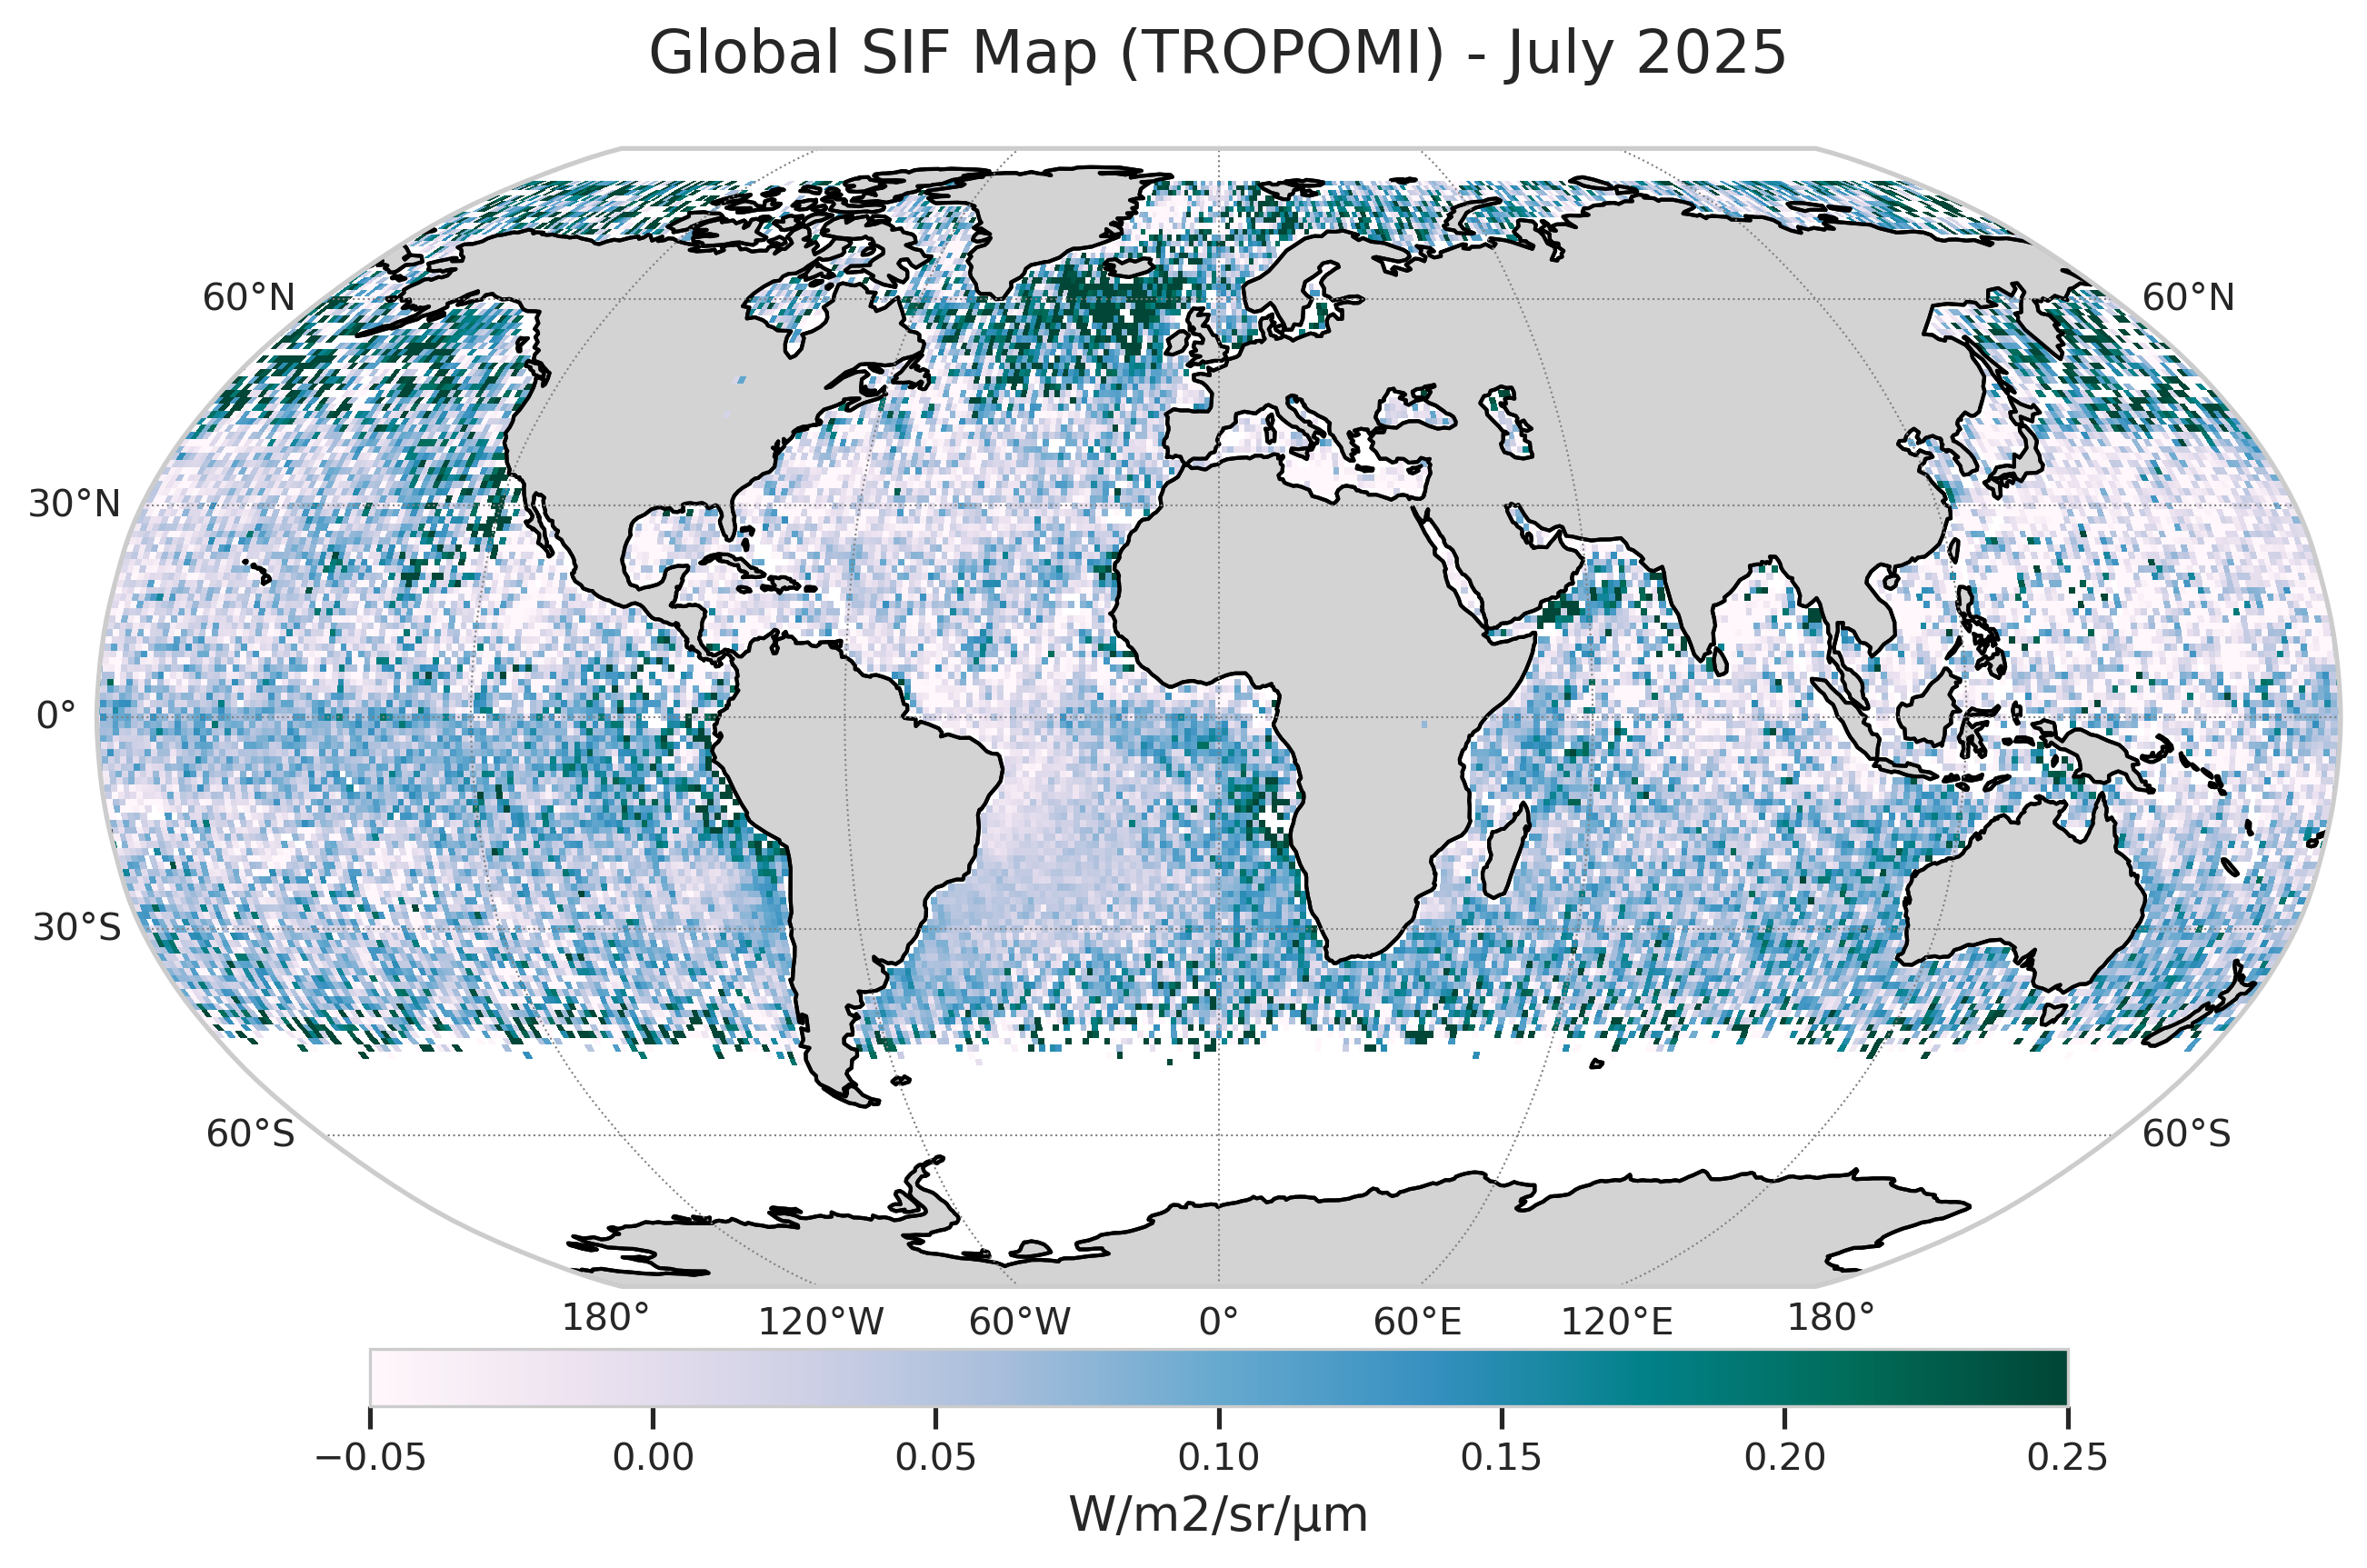

In [84]:
# draw a prettier global map for SIF
fig, ax = plt.subplots(figsize=(15, 6), subplot_kw={'projection': ccrs.Robinson()}, dpi=300)

# Add features for visual clarity
ax.add_feature(cfeature.LAND, zorder=0, edgecolor='black', facecolor='lightgrey')
# ax.add_feature(cfeature.OCEAN, zorder=0, facecolor='azure')
# ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=1)

# Gridlines with labels (longitude and latitude)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle=':')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

# Plot SIF with a better colormap and color limits
sif_cmap = plt.get_cmap('PuBuGn')  # winter
pcm = ax.pcolormesh(
    lon_tropomi, lat_tropomi, sif_tropomi,
    cmap=sif_cmap, vmin=-0.05, vmax=0.25,
    transform=ccrs.PlateCarree(), shading="auto",
)

cb = plt.colorbar(pcm, ax=ax, orientation="horizontal", pad=0.05, fraction=0.045, aspect=30)
cb.set_label("W/m2/sr/µm", fontsize=13)
cb.outline.set_linewidth(0.8)
cb.ax.tick_params(labelsize=10)

ax.set_title("Global SIF Map (TROPOMI) - July 2025", fontsize=16, pad=20)

plt.tight_layout()
plt.show()

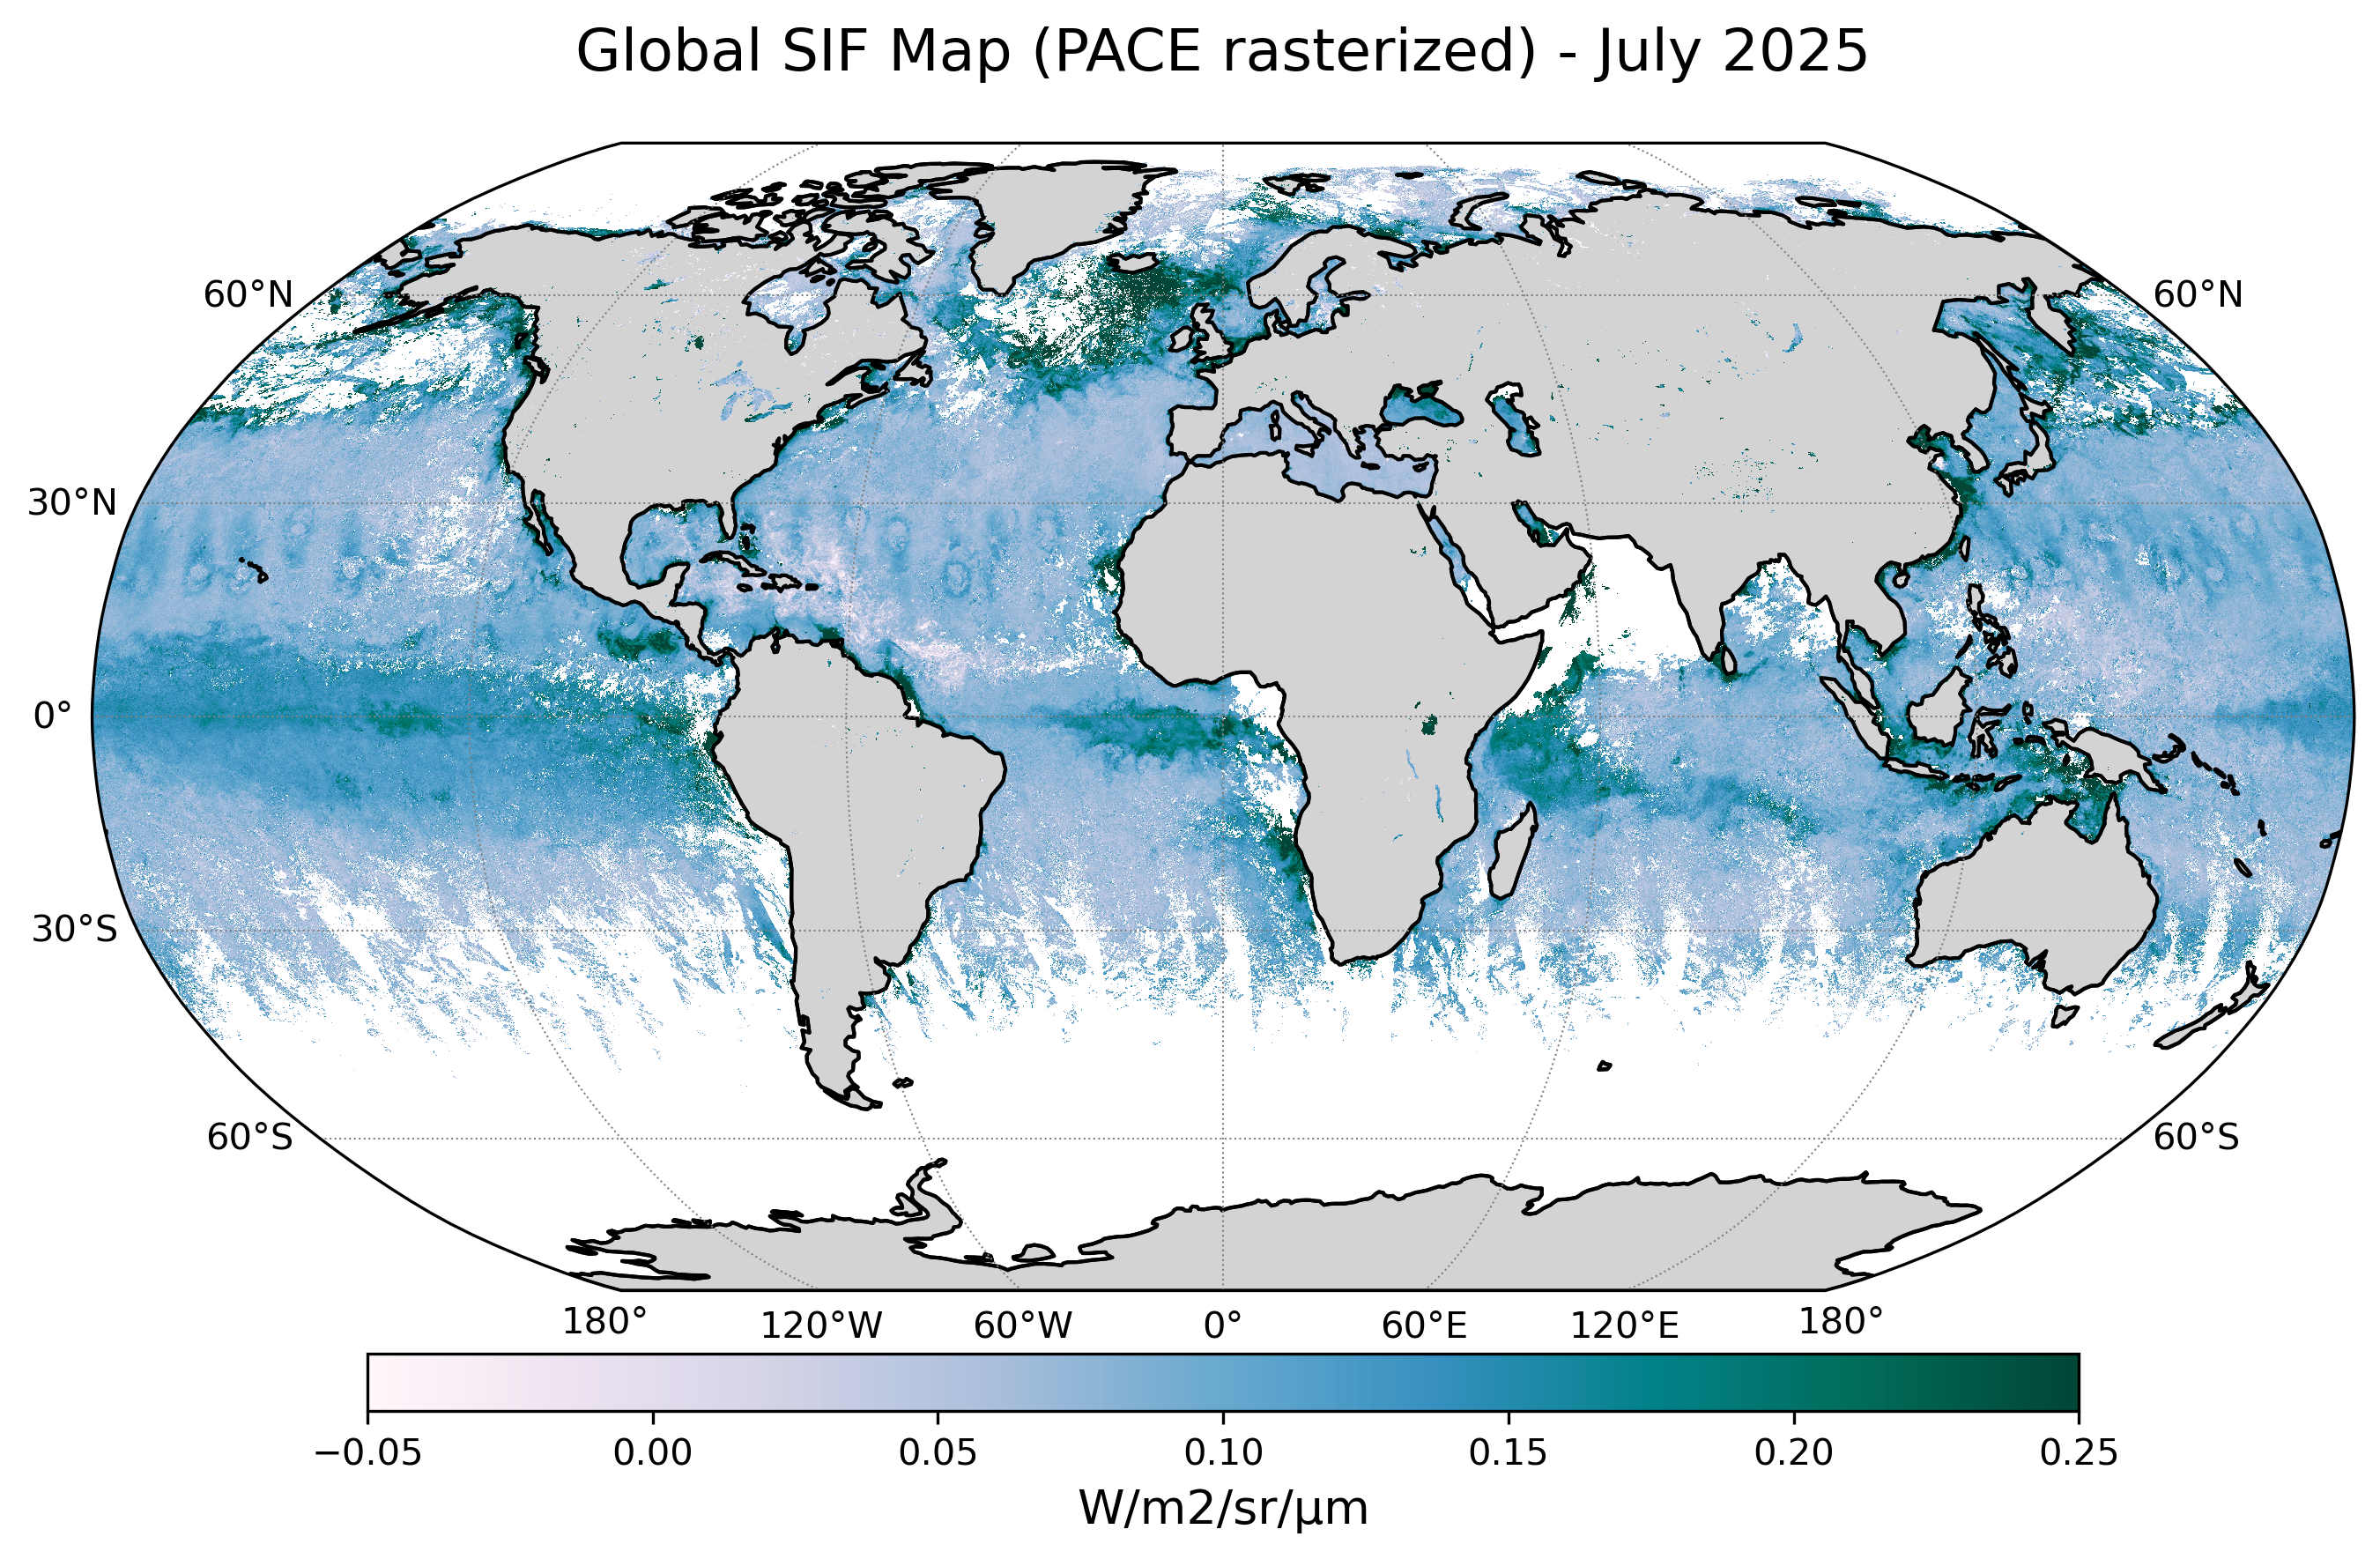

In [68]:
# PACE SVD rasterized SIF global map

pace_raster_file = "/home/zhe2/data/PACE/svd_rasterized/sif678_raster_20250630_20250730_0p1deg_partial.nc"
ds_pace = xr.open_dataset(pace_raster_file)

lon_pace = ds_pace["lon"]
lat_pace = ds_pace["lat"]
sif_pace = ds_pace["sif_radiance_678nm"]

# Plotting: similar prettier global map as before
fig, ax = plt.subplots(figsize=(15, 6), subplot_kw={'projection': ccrs.Robinson()}, dpi=300)

# Add features for visual clarity
ax.add_feature(cfeature.LAND, zorder=0, edgecolor='black', facecolor='lightgrey')
# ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=1)

# Gridlines with labels
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle=':')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

# Plot SIF as pcolormesh with a suitable colormap and color limits
sif_cmap = plt.get_cmap('PuBuGn')
pcm = ax.pcolormesh(
    lon_pace, lat_pace, sif_pace,
    cmap=sif_cmap, vmin=-0.05, vmax=0.25,
    transform=ccrs.PlateCarree(), shading="auto",
)

cb = plt.colorbar(pcm, ax=ax, orientation="horizontal", pad=0.05, fraction=0.045, aspect=30)
cb.set_label("W/m2/sr/µm", fontsize=13)
cb.outline.set_linewidth(0.8)
cb.ax.tick_params(labelsize=10)

ax.set_title("Global SIF Map (PACE rasterized) - July 2025", fontsize=16, pad=20)

plt.tight_layout()
plt.show()

In [67]:
# obtain July 2025 nFLH
import earthaccess
from datetime import datetime

earthaccess.login()

start_date = datetime(2025, 7, 1)
end_date   = datetime(2025, 7, 31)

results = earthaccess.search_data(
    short_name="PACE_OCI_L3M_FLH",
    temporal=(start_date.strftime("%Y-%m-%d"), end_date.strftime("%Y-%m-%d")),
)

results = [r for r in results if "0p1deg" in r.data_links()[0]]
results = [r for r in results if "MO" in r.data_links()[0]]

fo  = earthaccess.open(granules=[results[0]])
nflh_pace = xr.open_dataset(fo[0])
nflh_pace

/home/zhe2/anaconda3/envs/ocean/lib/python3.14/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/home/zhe2/anaconda3/envs/ocean/lib/python3.14/site-packages/earthaccess/store.py:516: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)
QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 907.27it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:01<00:00,  1.94s/it]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 26886.56it/s]


<xarray.Dataset> Size: 26MB
Dimensions:  (lat: 1800, lon: 3600, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat      (lat) float32 7kB 89.95 89.85 89.75 89.65 ... -89.75 -89.85 -89.95
  * lon      (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.8 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    nflh     (lat, lon) float32 26MB ...
    palette  (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/64)
    product_name:                      PACE_OCI.20250701_20250731.L3m.MO.FLH....
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    identifier_product_doi:            10.5067/PACE/OCI/L3M/FLH/3.1
    keywords:                          Earth Science > Oceans > Ocean Optics ...
    keywords_vocabulary:               NASA Global Change Master Directory (G...
    data_bins:                         3128053
    data_minimum:                      -3.4991324e-05
    data_maximum:                      4.840557

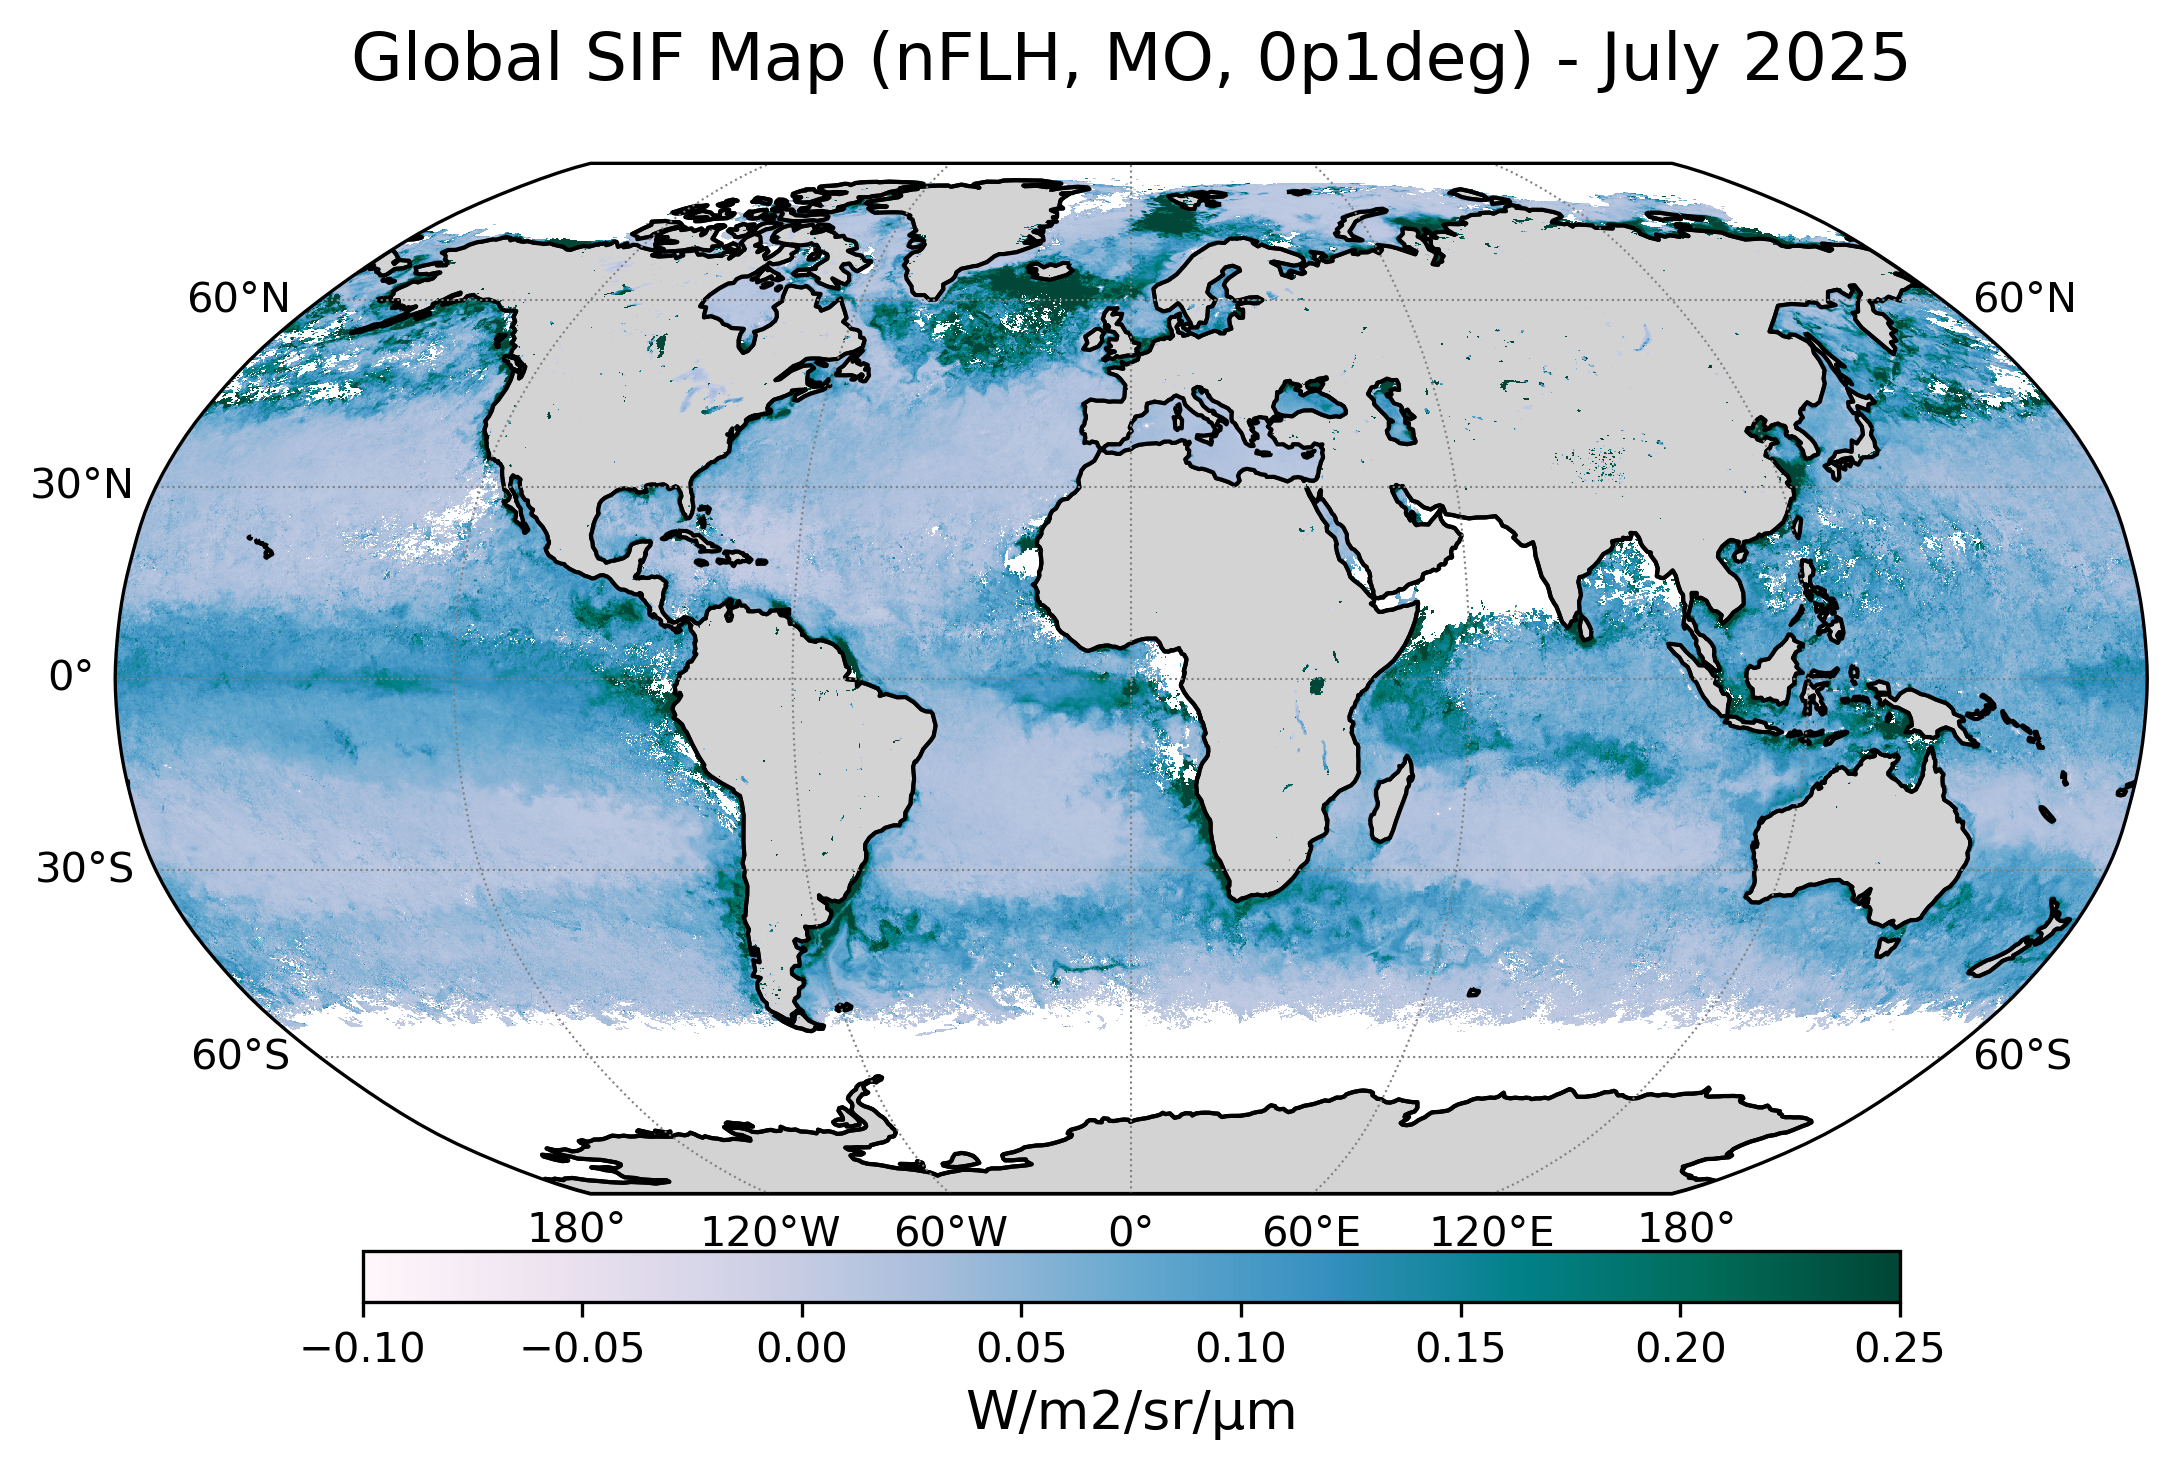

In [66]:
# map nflh_pace to global map
lon_nflh = nflh_pace["lon"]
lat_nflh = nflh_pace["lat"]
nflh = nflh_pace["nflh"]

# Plotting: similar prettier global map as before
fig, ax = plt.subplots(figsize=(15, 5), subplot_kw={'projection': ccrs.Robinson()}, dpi=300)

# Add features for visual clarity
ax.add_feature(cfeature.LAND, zorder=0, edgecolor='black', facecolor='lightgrey')
# ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=1)

# Gridlines with labels
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle=':')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

# Plot SIF as pcolormesh with a suitable colormap and color limits
sif_cmap = plt.get_cmap('PuBuGn')
pcm = ax.pcolormesh(
    lon_nflh, lat_nflh, nflh,
    cmap=sif_cmap, vmin=-0.1, vmax=0.25,
    transform=ccrs.PlateCarree(), shading="auto",
)

cb = plt.colorbar(pcm, ax=ax, orientation="horizontal", pad=0.05, fraction=0.045, aspect=30)
cb.set_label("W/m2/sr/µm", fontsize=13)
cb.outline.set_linewidth(0.8)
cb.ax.tick_params(labelsize=10)

ax.set_title("Global SIF Map (nFLH, MO, 0p1deg) - July 2025", fontsize=16, pad=20)

plt.tight_layout()
plt.show()

In [40]:
fo  = earthaccess.open(granules=[results[0]])
modis = xr.open_datatree(fo[0])

/home/zhe2/anaconda3/envs/ocean/lib/python3.14/site-packages/earthaccess/store.py:516: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)
QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 2109.81it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:01<00:00,  1.32s/it]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 11155.06it/s]


In [42]:
modis["level-3_binned_data"]

<xarray.DataTree 'level-3_binned_data'>
Group: /level-3_binned_data
    Dimensions:   (binListDim: 10865133, binDataDim: 10865133, binIndexDim: 4320)
    Dimensions without coordinates: binListDim, binDataDim, binIndexDim
    Data variables:
        BinList   (binListDim) [('bin_num', '<u4'), ('nobs', '<i2'), ('nscenes', '<i2'), ('weights', '<f4'), ('time_rec', '<f4')] 174MB ...
        nflh      (binDataDim) [('sum', '<f4'), ('sum_squared', '<f4')] 87MB ...
        ipar      (binDataDim) [('sum', '<f4'), ('sum_squared', '<f4')] 87MB ...
        BinIndex  (binIndexDim) [('start_num', '<u4'), ('begin', '<u4'), ('extent', '<u4'), ('max', '<u4')] 69kB ...

In [43]:
# # add modif nFLH
# start_date = datetime(2025, 7, 1)
# end_date   = datetime(2025, 7, 31)

# results = earthaccess.search_data(
#     short_name="MODISA_L3b_FLH",
#     temporal=(start_date.strftime("%Y-%m-%d"), end_date.strftime("%Y-%m-%d")),
# )

# results = [r for r in results if "20250731" in r.data_links()[0]]
# results = [r for r in results if "MO.FLH" in r.data_links()[0]]

# fo  = earthaccess.open(granules=[results[0]])
# modis = xr.open_dataset(fo[0])

# # map nflh_pace to global map
# lon_modis = modis["lon"]
# lat_modis = modis["lat"]
# nflh_modis = modis["nflh"]

# # Plotting: similar prettier global map as before
# fig, ax = plt.subplots(figsize=(15, 7), subplot_kw={'projection': ccrs.Robinson()})

# # Add features for visual clarity
# ax.add_feature(cfeature.LAND, zorder=0, edgecolor='black', facecolor='lightgrey')
# # ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.5)
# ax.add_feature(cfeature.COASTLINE, linewidth=1)

# # Gridlines with labels
# gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle=':')
# gl.top_labels = False
# gl.right_labels = False
# gl.xlabel_style = {'size': 10}
# gl.ylabel_style = {'size': 10}

# # Plot SIF as pcolormesh with a suitable colormap and color limits
# sif_cmap = plt.get_cmap('winter')
# pcm = ax.pcolormesh(
#     lon_modis, lat_modis, nflh_modis,
#     cmap=sif_cmap, vmin=-0.1, vmax=0.25,
#     transform=ccrs.PlateCarree(), shading="auto",
# )

# cb = plt.colorbar(pcm, ax=ax, orientation="horizontal", pad=0.05, fraction=0.045, aspect=30)
# cb.set_label("W/m2/sr/µm", fontsize=13)
# cb.outline.set_linewidth(0.8)
# cb.ax.tick_params(labelsize=10)

# ax.set_title("Global SIF Map (nFLH, MO, MODIS) - July 2025", fontsize=16, pad=20)

# plt.tight_layout()
# plt.show()

<>:35: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:35: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_761374/580085080.py:35: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_xlabel("Absolute fluorescence (W/m$^2$/sr/$\mu$m)", fontsize=14, labelpad=8)
/tmp/ipykernel_761374/580085080.py:12: RuntimeWarning: Mean of empty slice
  tropomi_lat_mean = np.nanmean(tropomi_sif_2d, axis=1)
/tmp/ipykernel_761374/580085080.py:13: RuntimeWarning: Mean of empty slice
  pace_lat_mean = np.nanmean(pace_sif_2d, axis=1)
/tmp/ipykernel_761374/580085080.py:14: RuntimeWarning: Mean of empty slice
  nflh_lat_mean = np.nanmean(nflh_2d, axis=1)


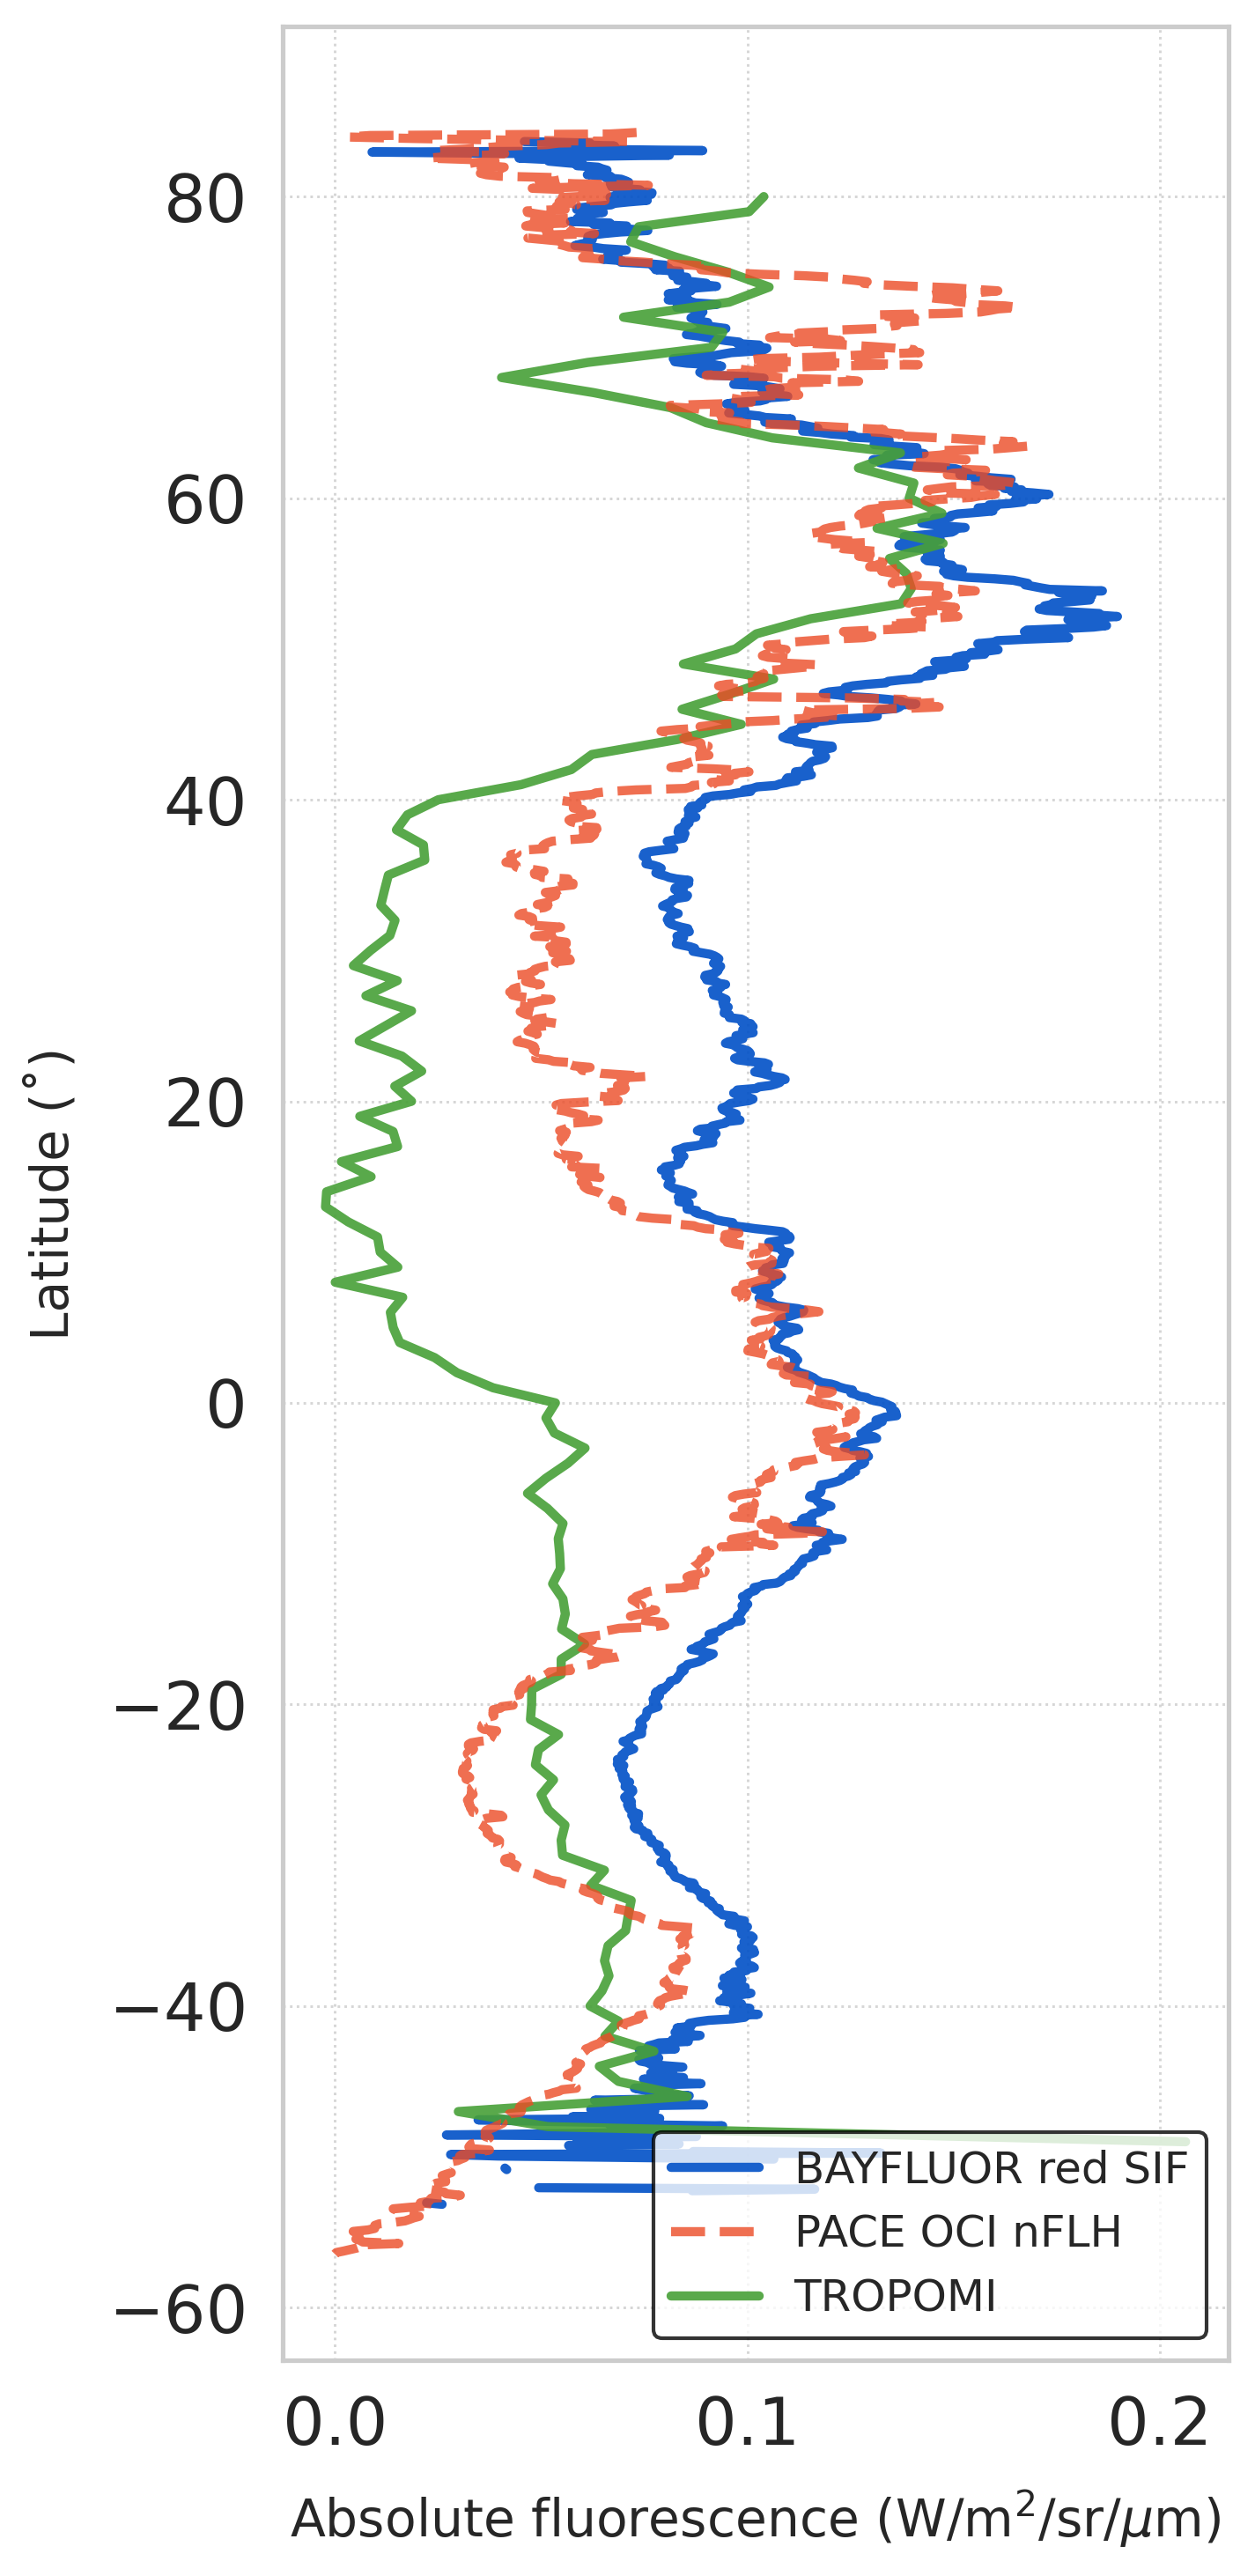

In [85]:
# Latitudinal mean SIF: TROPOMI vs PACE vs PACE nFLH (requires cells 1, 3, and 6)

tropomi_sif_2d = ds_tropomi["sif"].values
tropomi_lat_1d = ds_tropomi["lat"].values
pace_sif_2d = ds_pace["sif_radiance_678nm"].values
pace_lat_1d = ds_pace["lat"].values

# Add PACE nFLH (MO L3m) - make sure shape/axis are correct
nflh_2d = nflh_pace["nflh"].values
nflh_lat_1d = nflh_pace["lat"].values

tropomi_lat_mean = np.nanmean(tropomi_sif_2d, axis=1)
pace_lat_mean = np.nanmean(pace_sif_2d, axis=1)
nflh_lat_mean = np.nanmean(nflh_2d, axis=1)

plt.rcParams.update({'font.family': 'DejaVu Sans'})

fig, ax = plt.subplots(figsize=(5, 10), dpi=300)
ax.plot(
    pace_lat_mean, pace_lat_1d, 
    label="BAYFLUOR red SIF", color="#0050C7", linewidth=2.5, zorder=3,
    alpha=0.9
)
ax.plot(
    nflh_lat_mean, nflh_lat_1d, 
    label="PACE OCI nFLH", color="#EC4B26", linewidth=2.5, linestyle="--",
    zorder=5, alpha=0.8
)
ax.plot(
    tropomi_lat_mean, tropomi_lat_1d, 
    label="TROPOMI", color="#47A037", linewidth=2.5, zorder=4, 
    alpha=0.9
)

ax.set_xlabel("Absolute fluorescence (W/m$^2$/sr/$\mu$m)", fontsize=14, labelpad=8)
ax.set_ylabel("Latitude (˚)", fontsize=14, labelpad=8)

# Correct approach: set tick label size via tick_params, not get_xticklabels/get_yticklabels
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

# ax.set_title(
#     "Latitudinal Mean SIF (July 2025)\nPACE (rasterized) | TROPOMI | PACE nFLH L3m",
#     fontsize=15, pad=22, weight='bold'
# )
ax.legend(fontsize=12, loc="lower right", frameon=True, facecolor='white', edgecolor='black')
ax.grid(True, linestyle=":", which="both", linewidth=0.7, alpha=0.8, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

Co-located valid 0.1° pixels: 2,109,908
bias (nFLH - SVD SIF): -0.0260
RMSE: 0.0648
r: 0.7076


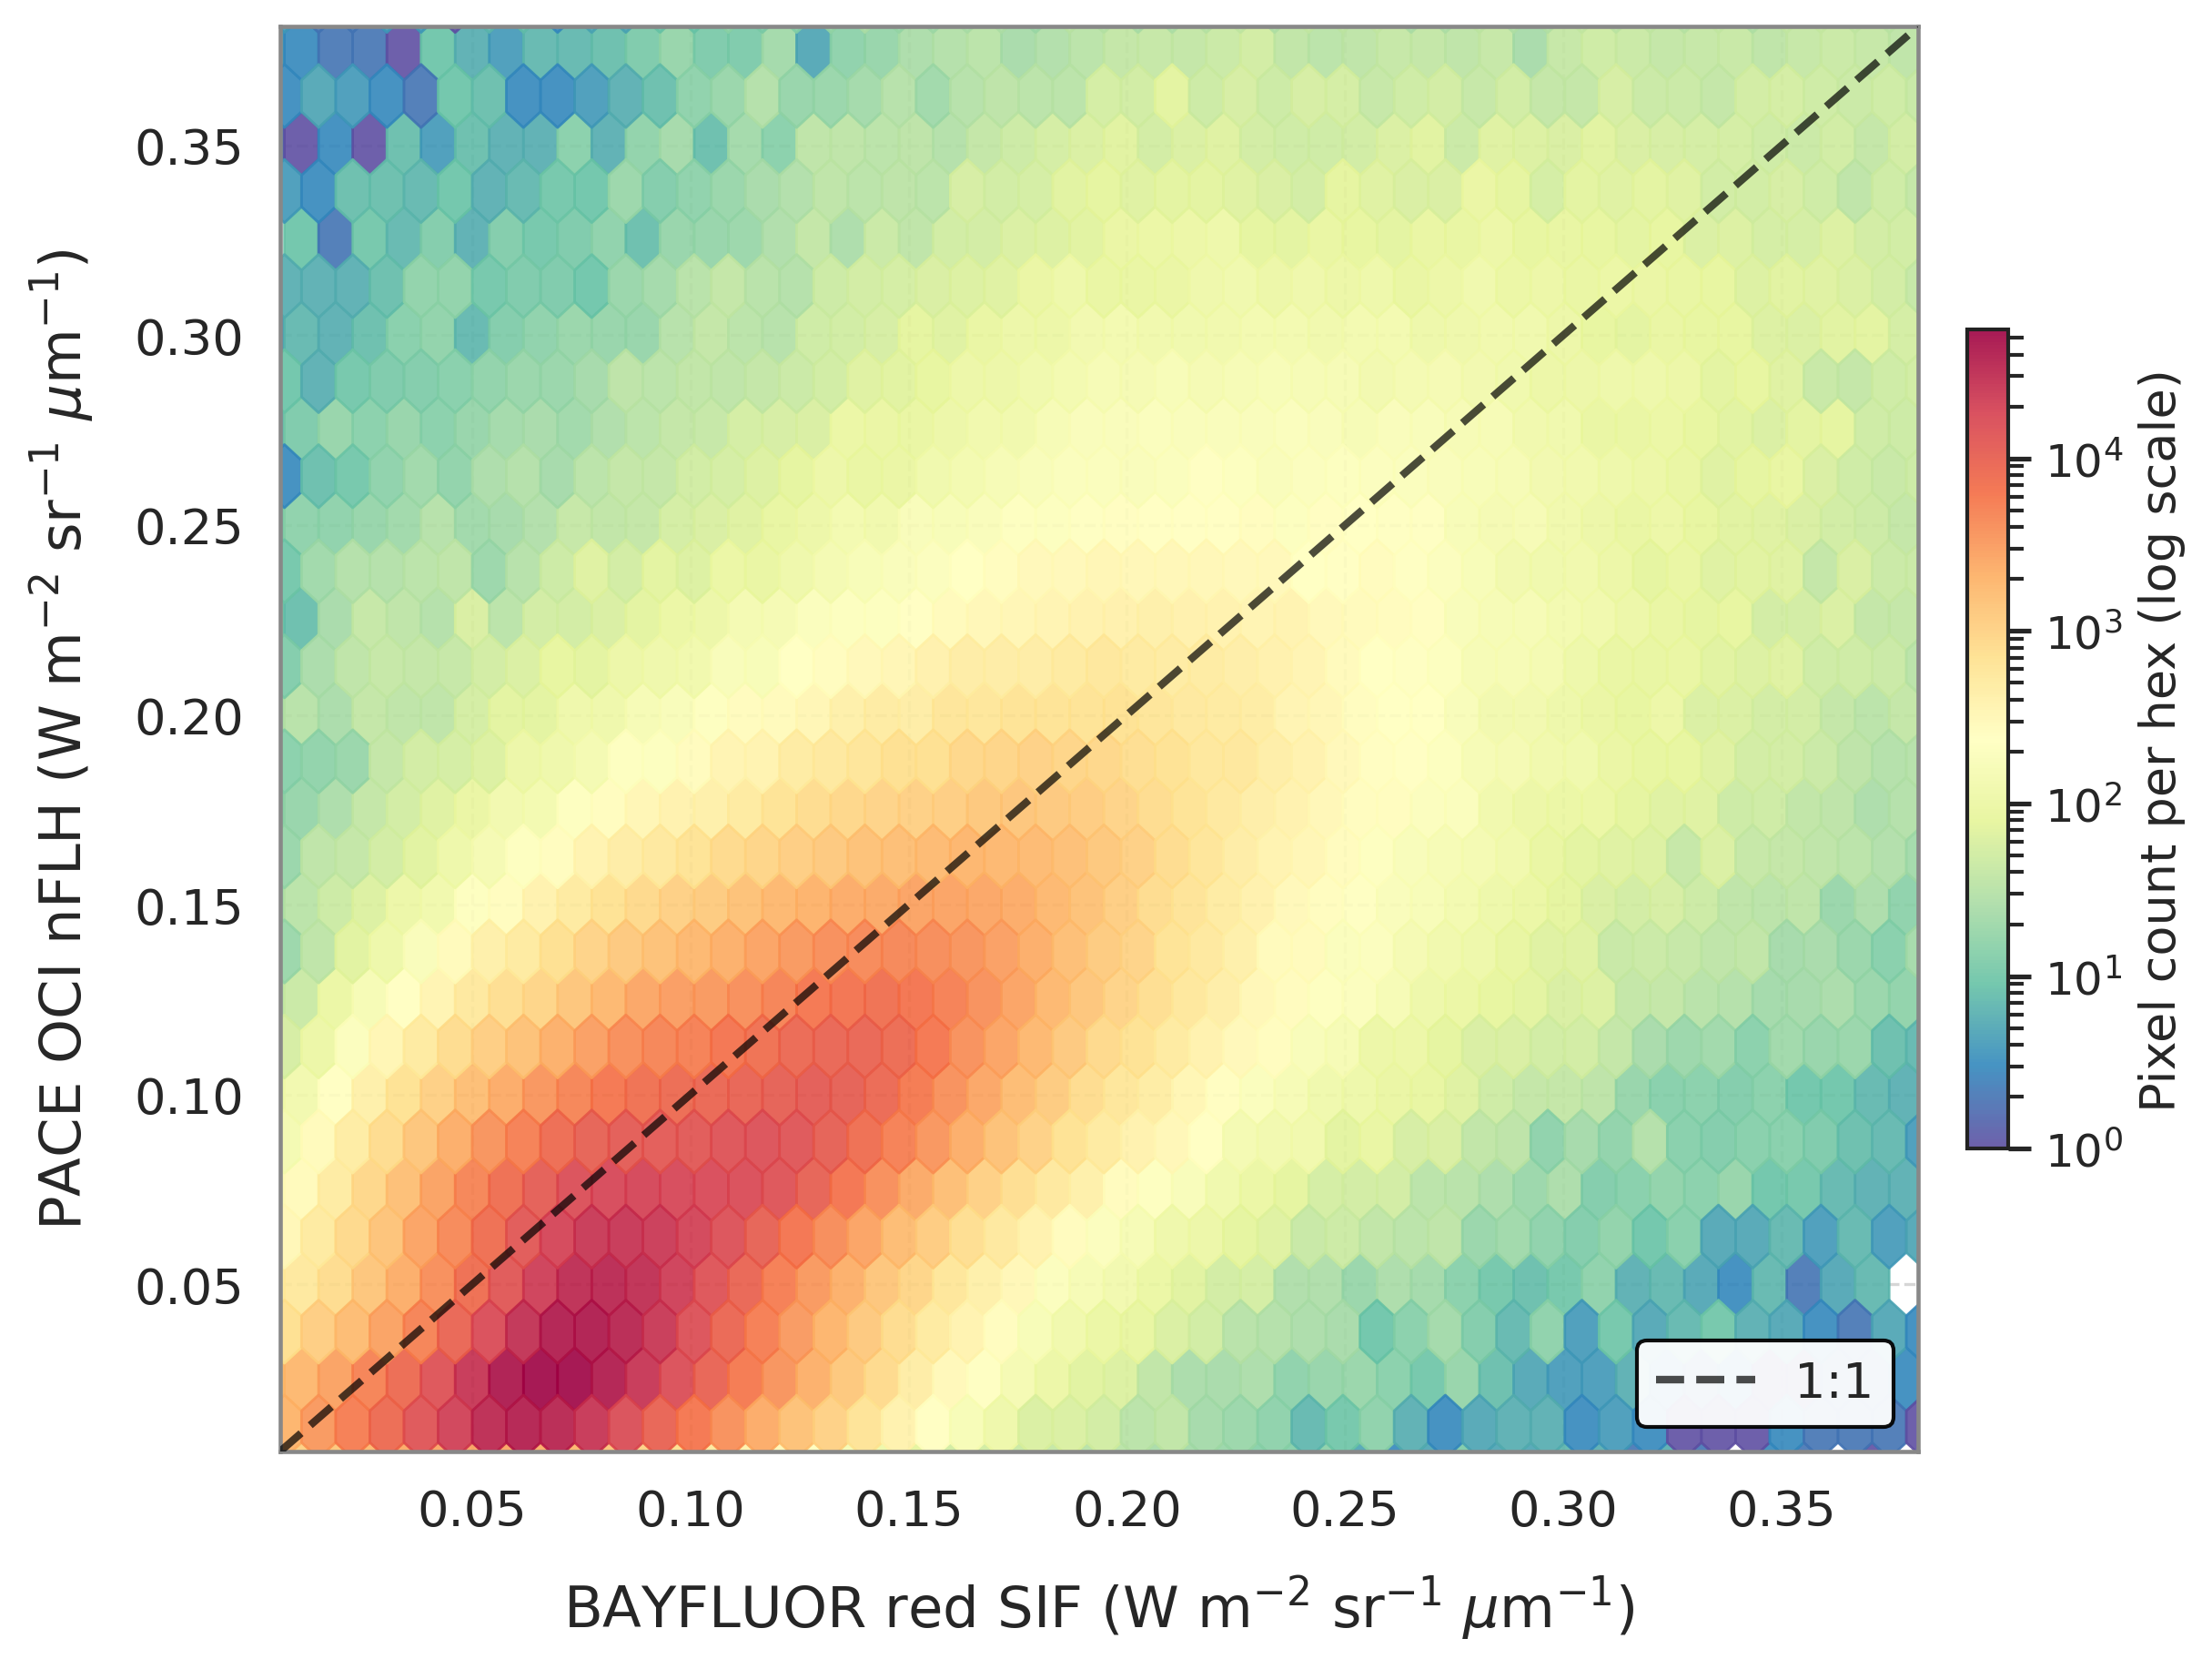

In [87]:
# PACE SVD SIF vs PACE L3m nFLH @ 0.1° — hexbin comparison, prettier version

from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

# Use a nicer style and larger default font
sns.set_context("notebook", font_scale=1.25)
sns.set_style("whitegrid", {'grid.linestyle': ':'})

pace_sif_2d = ds_pace["sif_radiance_678nm"]
nflh_2d = nflh_pace["nflh"].interp(
    lat=pace_sif_2d["lat"],
    lon=pace_sif_2d["lon"],
    method="nearest",
)

pace_sif_flat = pace_sif_2d.values.astype(float)
nflh_flat = nflh_2d.values.astype(float)

valid = (
    np.isfinite(pace_sif_flat)
    & np.isfinite(nflh_flat)
    & (pace_sif_flat > -900)
    & (nflh_flat > -900)
)
x_pace_sif = pace_sif_flat[valid]
y_nflh = nflh_flat[valid]

print(f"Co-located valid 0.1° pixels: {valid.sum():,}")

bias = np.nanmean(y_nflh - x_pace_sif)
rmse = np.sqrt(np.nanmean((y_nflh - x_pace_sif) ** 2))
r = np.corrcoef(x_pace_sif, y_nflh)[0, 1]
print(f"bias (nFLH - SVD SIF): {bias:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"r: {r:.4f}")

lims = np.nanpercentile(np.concatenate([x_pace_sif, y_nflh]), [1, 99])

# Set figure to a rectangle, e.g., wider than tall
fig, ax = plt.subplots(figsize=(8, 6), dpi=300, constrained_layout=True)
hb = ax.hexbin(
    x_pace_sif,
    y_nflh,
    gridsize=225,
    cmap="Spectral_r",
    mincnt=1,
    linewidths=0.65,
    # edgecolors='k',
    norm=LogNorm(vmin=1),  # log scaling for counts
    alpha=0.9,
)
# 1:1 diagonal line
ax.plot(lims, lims, "k--", lw=2, label="1:1", alpha=0.7, zorder=10)
ax.set_xlim(lims)
ax.set_ylim(lims)
# Do NOT force aspect ratio
# ax.set_aspect("equal")  # --- removed to prevent forced aspect ratio

ax.set_xlabel(r"BAYFLUOR red SIF (W m$^{-2}$ sr$^{-1}$ $\mu$m$^{-1}$)", fontsize=15, labelpad=10)
ax.set_ylabel(r"PACE OCI nFLH (W m$^{-2}$ sr$^{-1}$ $\mu$m$^{-1}$)", fontsize=15, labelpad=10)

ax.xaxis.set_tick_params(labelsize=13)
ax.yaxis.set_tick_params(labelsize=13)

# ax.set_title(
#     "PACE SVD SIF vs. PACE nFLH (0.1° July 2025)", 
#     fontsize=17, pad=18, weight='bold'
# )
legend = ax.legend(
    loc="lower right", fontsize=13,
    frameon=True, facecolor='white', edgecolor='black', framealpha=0.94
)

# Statistical annotation box, bottom right
# stats_text = (
#     rf"$\bf{{N}}$: {valid.sum():,}" "\n"
#     rf"$\bf{{Bias}}$: {bias:.4f}" "\n"
#     rf"$\bf{{RMSE}}$: {rmse:.4f}" "\n"
#     rf"$\bf{{r}}$: {r:.3f}"
# )
# ax.annotate(
#     stats_text,
#     xy=(0.98, 0.03), xycoords="axes fraction",
#     ha="right", va="bottom",
#     fontsize=12,
#     bbox=dict(boxstyle="round,pad=0.36", facecolor="#F6F6F6", lw=1.2, edgecolor="#737373", alpha=0.94)
# )

# Colorbar — log scale hexbin density
cb1 = fig.colorbar(hb, ax=ax, pad=0.03, orientation="vertical", fraction=.025)
cb1.set_label("Pixel count per hex (log scale)", fontsize=13)
cb1.ax.tick_params(labelsize=12)
cb1.outline.set_linewidth(1)
cb1.outline.set_edgecolor("#222222")

# # Second colorbar, linear scale, just for visual comparison (not used in data)
# divider = make_axes_locatable(ax)
# cax2 = divider.append_axes("right", size="2.5%", pad=0.12)
# hb_linear = ax.hexbin(
#     [], [], gridsize=225, cmap="Spectral_r", mincnt=1, linewidths=0.7, edgecolors='k'
# )
# cb2 = fig.colorbar(hb_linear, cax=cax2, orientation="vertical")
# cb2.set_label("Pixel count per hex (linear)", fontsize=11)
# cb2.set_ticks([])  # visual only
# cb2.ax.spines['left'].set_visible(False)
# cb2.outline.set_linewidth(1)
# cb2.outline.set_edgecolor("#222222")

# Make grid and spines subtle in color
ax.grid(True, linestyle="--", linewidth=0.8, color="#CCC", alpha=0.8, zorder=0)
for spine in ax.spines.values():
    spine.set_edgecolor("#888888")
    spine.set_linewidth(1.1)

plt.show()
